# Hyperparameter Exploration: Number of Fully Connected Layers

## Approach & Assumptions

This notebook explores how the **number of fully connected (Dense) layers** influences the prediction accuracy and inference time of a CNN trained on the HaGRID gesture dataset (subset: *like*, *peace*, *rock*).

### Hypothesis
More fully connected layers allow the network to learn more abstract and complex decision boundaries, which should improve accuracy — up to a point. Beyond a certain depth, additional layers may cause overfitting or vanishing gradients, leading to worse generalization on the small dataset. We also expect inference time to increase slightly with more layers, since each additional layer adds matrix multiplications at prediction time.

### Tested Values
We test **1, 2, 3, and 4** fully connected layers. These span the realistic range for a small CNN: 1 is the minimal case (just a classifier head), while 4 layers represents a relatively deep fully connected stack for this image size and dataset.

### Controlled Variables
All other hyperparameters are kept constant: image size (64×64), color (RGB), batch size (32), optimizer (Adam), dropout (0.2), 3 convolutional layers with leaky ReLU activation, 64 neurons per Dense layer, early stopping with patience 3.

In [1]:
import cv2
import json
import numpy as np
import os
import time
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, RandomFlip, RandomContrast
from keras.metrics import categorical_crossentropy
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.notebook import tqdm

CONDITIONS = ['like', 'peace', 'rock']
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)
COLOR_CHANNELS = 3
PATH = '../gesture_dataset_sample'

## Load and Preprocess Data

In [2]:
annotations = {}
for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

def preprocess_image(img):
    return cv2.resize(img, SIZE)

images, labels, label_names = [], [], []

for condition in CONDITIONS:
    img_dir = f'{PATH}/{condition}'
    for filename in tqdm(os.listdir(img_dir), desc=condition):
        UID = filename.split('.')[0]
        img = cv2.imread(f'{img_dir}/{filename}')
        if img is None:
            continue
        try:
            annotation = annotations[condition][UID]
        except KeyError:
            continue
        for i, bbox in enumerate(annotation['bboxes']):
            label = annotation['labels'][i]
            if label not in CONDITIONS:
                continue
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w  = int(bbox[2] * img.shape[1])
            h  = int(bbox[3] * img.shape[0])
            crop = img[y1:y1+h, x1:x1+w]
            if crop.size == 0:
                continue
            if label not in label_names:
                label_names.append(label)
            images.append(preprocess_image(crop))
            labels.append(label_names.index(label))

print(f'Total images: {len(images)}, Classes: {label_names}')

like:   0%|          | 0/250 [00:00<?, ?it/s]

peace:   0%|          | 0/250 [00:00<?, ?it/s]

rock:   0%|          | 0/250 [00:00<?, ?it/s]

Total images: 750, Classes: ['like', 'peace', 'rock']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

X_train = np.array(X_train).astype('float32') / 255.
X_test  = np.array(X_test).astype('float32')  / 255.
X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test  = X_test.reshape(-1,  IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

y_train_oh = to_categorical(y_train, num_classes=len(label_names))
y_test_oh  = to_categorical(y_test,  num_classes=len(label_names))

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (600, 64, 64, 3), Test: (150, 64, 64, 3)


## Train Models for Each Value of `num_fc_layers`

We train one model per configuration (1, 2, 3, 4 fully connected layers) and record:
- Final **test accuracy**
- **Inference time** per image (averaged over the test set)
- Training **history** (accuracy + loss curves)

In [4]:
def build_model(num_fc_layers):
    model = Sequential([
        RandomFlip('horizontal'),
        RandomContrast(0.1),
        Conv2D(64, (9, 9), activation='leaky_relu',
               input_shape=(IMG_SIZE, IMG_SIZE, COLOR_CHANNELS), padding='same'),
        MaxPooling2D((4, 4), padding='same'),
        Conv2D(32, (5, 5), activation='leaky_relu', padding='same'),
        MaxPooling2D((3, 3), padding='same'),
        Conv2D(32, (3, 3), activation='leaky_relu', padding='same'),
        MaxPooling2D((2, 2), padding='same'),
        Dropout(0.2),
        Flatten(),
    ])
    for _ in range(num_fc_layers):
        model.add(Dense(64, activation='relu'))
    model.add(Dense(len(label_names), activation='softmax'))
    model.compile(loss=categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
    return model

FC_LAYER_VALUES = [1, 2, 3, 4]
results = {}

for num_fc in FC_LAYER_VALUES:
    print(f'\n=== Training with {num_fc} fully connected layer(s) ===')
    model = build_model(num_fc)

    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    stop_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_oh,
        batch_size=32,
        epochs=50,
        verbose=1,
        validation_data=(X_test, y_test_oh),
        callbacks=[reduce_lr, stop_early]
    )

    _, acc = model.evaluate(X_test, y_test_oh, verbose=0)

    # measure average inference time per single image
    times = []
    for img in X_test:
        inp = img.reshape(1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
        t0 = time.perf_counter()
        model.predict(inp, verbose=0)
        times.append(time.perf_counter() - t0)
    avg_inference_ms = np.mean(times) * 1000

    results[num_fc] = {
        'accuracy': acc,
        'inference_ms': avg_inference_ms,
        'history': history.history,
    }
    print(f'  -> Accuracy: {acc:.4f} | Avg inference: {avg_inference_ms:.2f} ms')


=== Training with 1 fully connected layer(s) ===
Epoch 1/50


/Users/jonastaigel/Desktop/ss26/interactiontechnologies/04/assignment-05-cnn-jonez-x/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3600 - loss: 1.1132 - val_accuracy: 0.2867 - val_loss: 1.1060 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3783 - loss: 1.0926 - val_accuracy: 0.3800 - val_loss: 1.0788 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4017 - loss: 1.0600 - val_accuracy: 0.4067 - val_loss: 1.0727 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.4767 - loss: 1.0029 - val_accuracy: 0.4600 - val_loss: 0.9509 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6317 - loss: 0.7850 - val_accuracy: 0.6467 - val_loss: 0.7410 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7317 - loss: 0.6294 - val_accuracy: 0.8267 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8267 - loss: 0.4378 - val_accuracy: 0.82

## Results: Accuracy & Inference Time

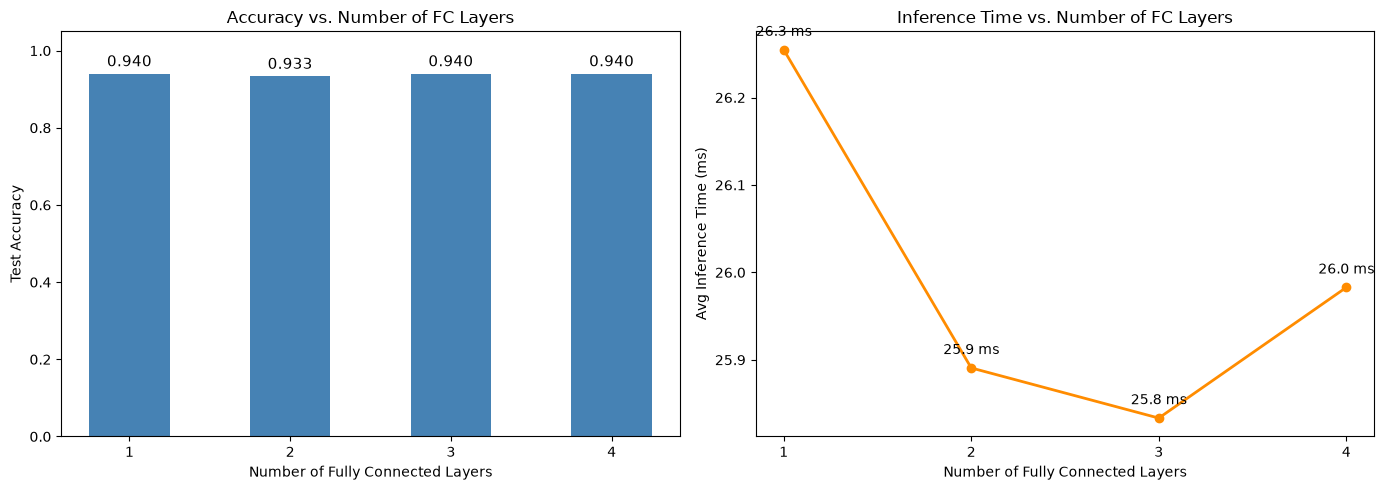

In [5]:
fc_vals     = FC_LAYER_VALUES
accuracies  = [results[n]['accuracy']     for n in fc_vals]
infer_times = [results[n]['inference_ms'] for n in fc_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar([str(n) for n in fc_vals], accuracies, color='steelblue', width=0.5)
ax1.set_xlabel('Number of Fully Connected Layers')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Accuracy vs. Number of FC Layers')
ax1.set_ylim(0, 1.05)
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)

ax2.plot([str(n) for n in fc_vals], infer_times, marker='o', color='darkorange', linewidth=2)
ax2.set_xlabel('Number of Fully Connected Layers')
ax2.set_ylabel('Avg Inference Time (ms)')
ax2.set_title('Inference Time vs. Number of FC Layers')
for x, y in zip([str(n) for n in fc_vals], infer_times):
    ax2.annotate(f'{y:.1f} ms', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('results_summary.png', dpi=150)
plt.show()

## Training Curves per Configuration

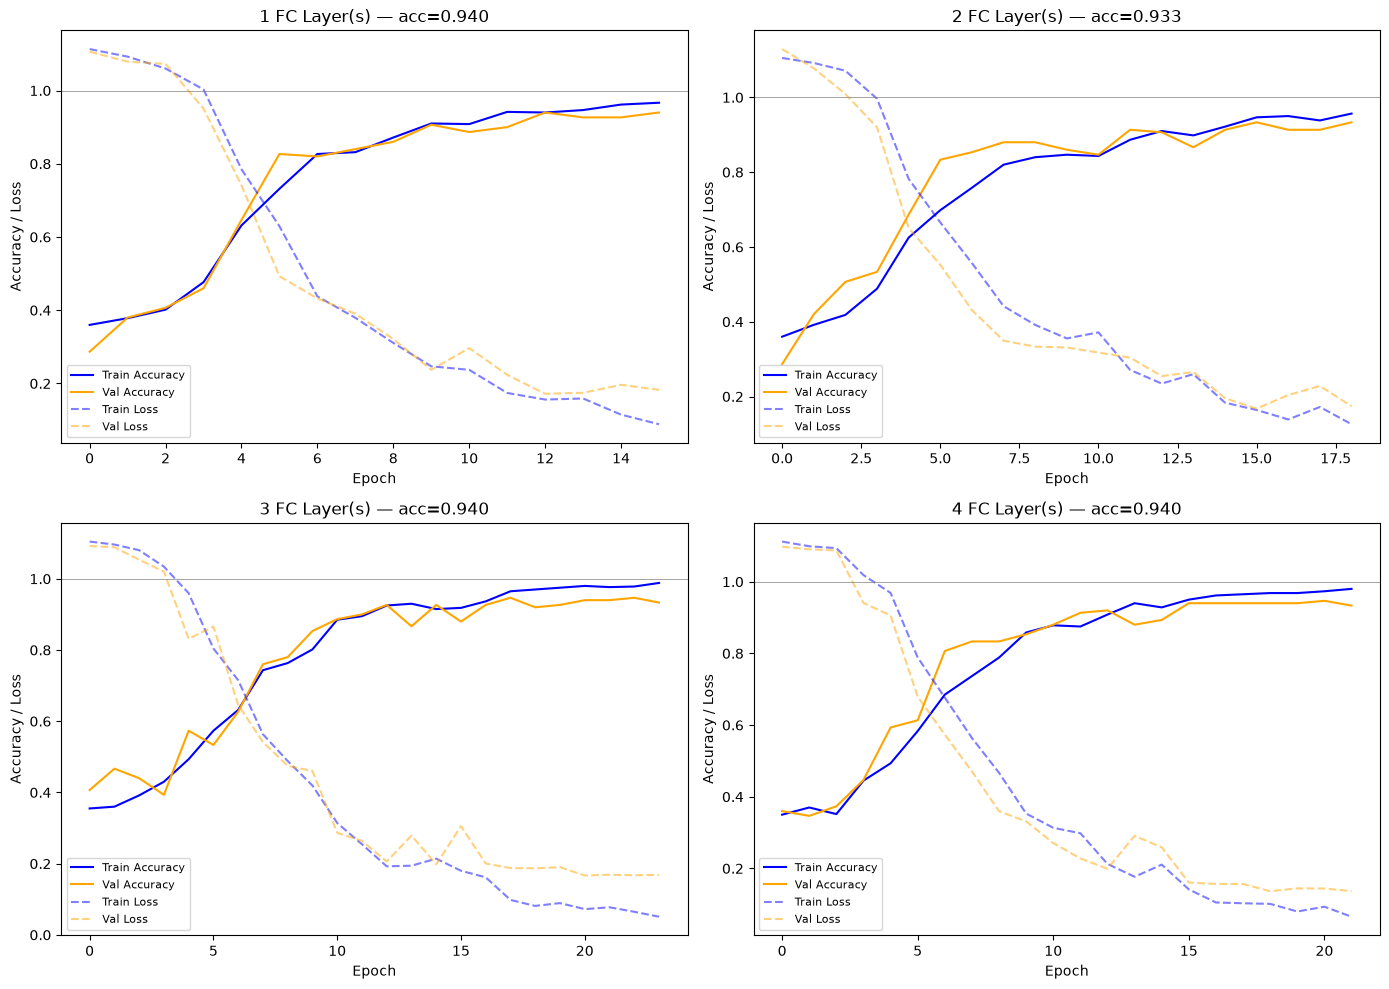

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, num_fc in enumerate(fc_vals):
    h = results[num_fc]['history']
    ax = axes[i]
    ax.plot(h['accuracy'],     color='blue',   label='Train Accuracy')
    ax.plot(h['val_accuracy'], color='orange', label='Val Accuracy')
    ax.plot(h['loss'],         color='blue',   linestyle='--', alpha=0.5, label='Train Loss')
    ax.plot(h['val_loss'],     color='orange', linestyle='--', alpha=0.5, label='Val Loss')
    ax.set_title(f'{num_fc} FC Layer(s) — acc={results[num_fc]["accuracy"]:.3f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy / Loss')
    ax.legend(fontsize=8)
    ax.axhline(1, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Summary Table

In [7]:
print(f'{"FC Layers":<12} {"Accuracy":<12} {"Inference (ms)":<18} {"Epochs trained"}')
print('-' * 58)
for n in fc_vals:
    r = results[n]
    epochs = len(r['history']['accuracy'])
    print(f'{n:<12} {r["accuracy"]:<12.4f} {r["inference_ms"]:<18.2f} {epochs}')

FC Layers    Accuracy     Inference (ms)     Epochs trained
----------------------------------------------------------
1            0.9400       26.25              16
2            0.9333       25.89              19
3            0.9400       25.83              24
4            0.9400       25.98              22


## Discussion

| FC Layers | Accuracy | Inference (ms) | Epochs trained |
|-----------|----------|----------------|----------------|
| 1         | 0.9400   | 26.25          | 16             |
| 2         | 0.9333   | 25.89          | 19             |
| 3         | 0.9400   | 25.83          | 24             |
| 4         | 0.9400   | 25.98          | 22             |

The results show that the number of fully connected layers has surprisingly little impact on final accuracy for this dataset and architecture:

- **Accuracy**: Three configurations (1, 3, and 4 FC layers) achieved the same best accuracy of 0.9400. Only 2 layers performed marginally worse at 0.9333. This suggests the convolutional layers already extract most of the discriminative features, and the fully connected head mainly needs to classify them — a single dense layer is sufficient for that.
- **Inference time**: Contrary to expectations, inference time did not increase with more layers — all values are within ~0.5 ms of each other (~26 ms). This confirms that the dense layers contribute negligible computation compared to the convolutional stack.
- **Training efficiency**: The model with 1 FC layer converged fastest (16 epochs), while deeper configurations required more epochs (up to 24), indicating that extra layers slow down convergence without improving the final result.
- **Conclusion**: For this small gesture dataset, **1 fully connected layer** is the optimal choice — it matches the best accuracy while converging fastest and keeping the model simple. Adding more layers only increases training time without benefit.